# 02 - Exploratory analysis and stationarity

**Part 1 of the assignment (continued).** Visual EDA of the hourly appliance energy series, decomposition into trend/seasonal/residual components, and the full stationarity test battery (ADF, KPSS, ACF/PACF, differencing) that Part 4's SARIMAX model depends on.

In [1]:
import os

# Must be set before numpy/torch are imported. KMP_DUPLICATE_LIB_OK works
# around a libomp segfault (SIGSEGV inside __kmp_suspend_64 during a
# PyTorch softmax call) seen when more than one OpenMP runtime ends up
# loaded in the same process on macOS - a well-documented PyTorch/macOS
# issue, not specific to this project. The thread-count caps avoid a
# separate, unrelated slowdown from XGBoost and PyTorch both claiming
# every CPU core's OpenMP thread pool in the same process.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
_N_THREADS = str(max(1, (os.cpu_count() or 4) // 2))
for _v in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(_v, _N_THREADS)

import sys
from pathlib import Path

SRC_DIR = Path.cwd().parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import config, data as D, features as F, evaluation as E, plotting as P
from appliance_energy.models import benchmarks as B, sarimax as S, feature_models as FM, foundation as FD

%matplotlib inline


In [2]:
hourly = D.load_hourly_data()
y = hourly[config.TARGET]
y.describe()

Loading cached hourly data from /Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/data/processed/appliance_hourly.csv


count    3290.000000
mean       97.779129
std        81.213695
min        28.333333
25%        50.000000
50%        63.333333
75%       110.000000
max       608.333333
Name: Appliances, dtype: float64

## Full series and a zoomed-in window

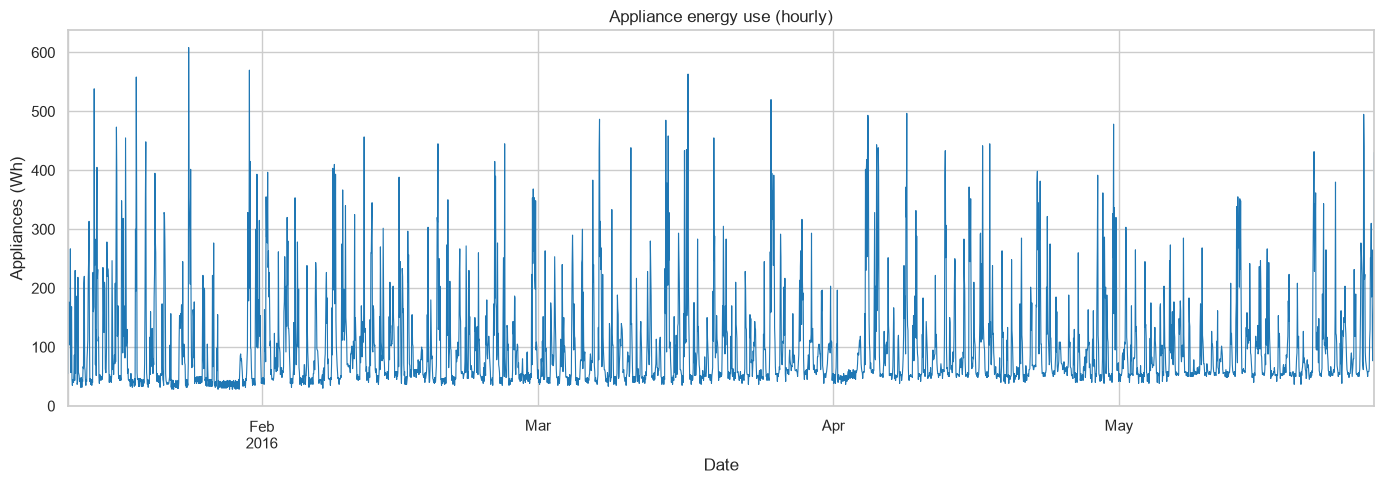

In [3]:
P.plot_full_series(y); plt.show()

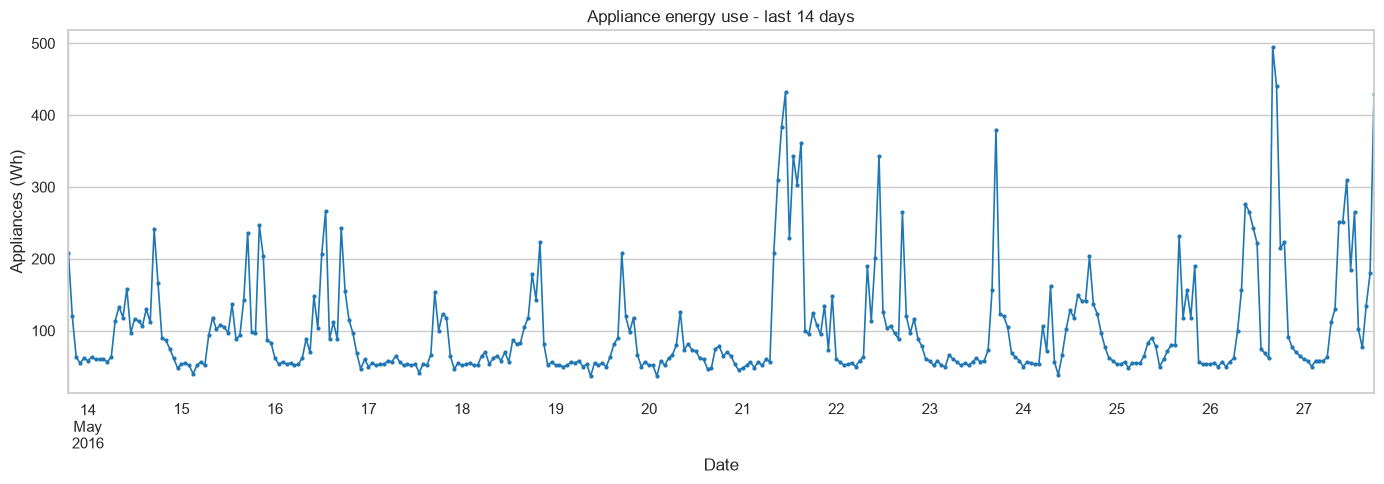

In [4]:
P.plot_series_window(y, days=14); plt.show()

## Hourly and weekly profile

Boxplots of usage by hour-of-day and day-of-week make the *shape* of any seasonal component directly visible before we test for it statistically.

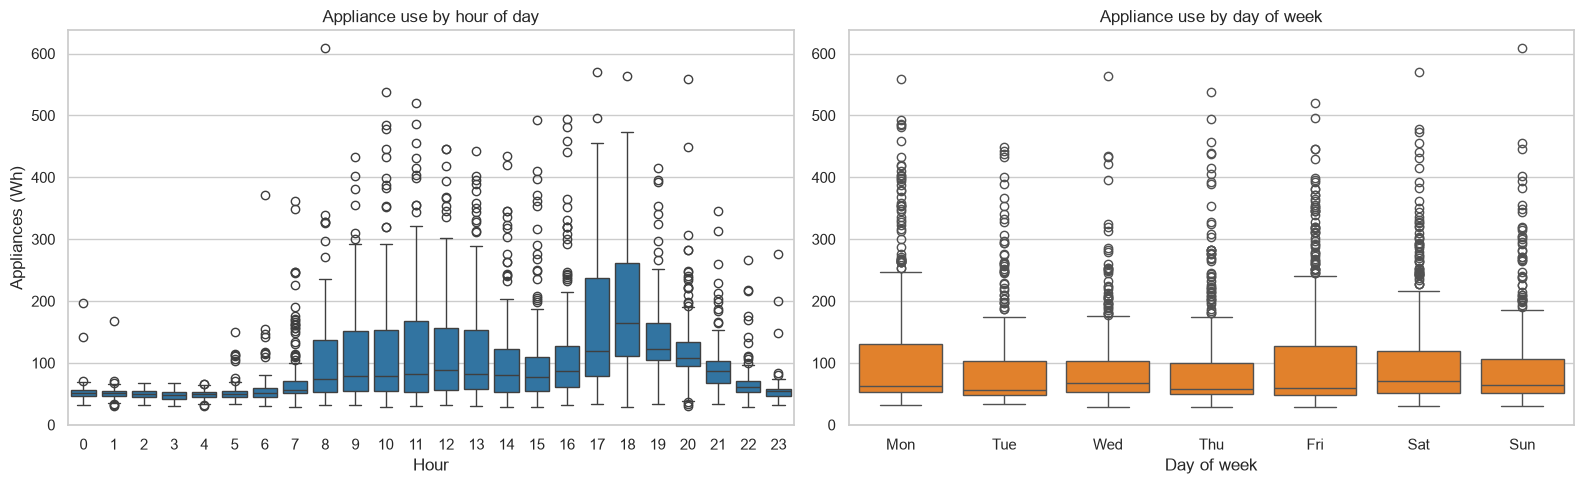

In [5]:
P.plot_hourly_and_weekday_profiles(y); plt.show()

## Seasonal-trend decomposition (STL)

STL decomposes the series into trend, (daily) seasonal, and residual components. We use STL rather than the simpler classical additive decomposition because it is robust to a seasonal shape that isn't a perfect sinusoid and to occasional outlier days, both of which are plausible for real household behaviour.

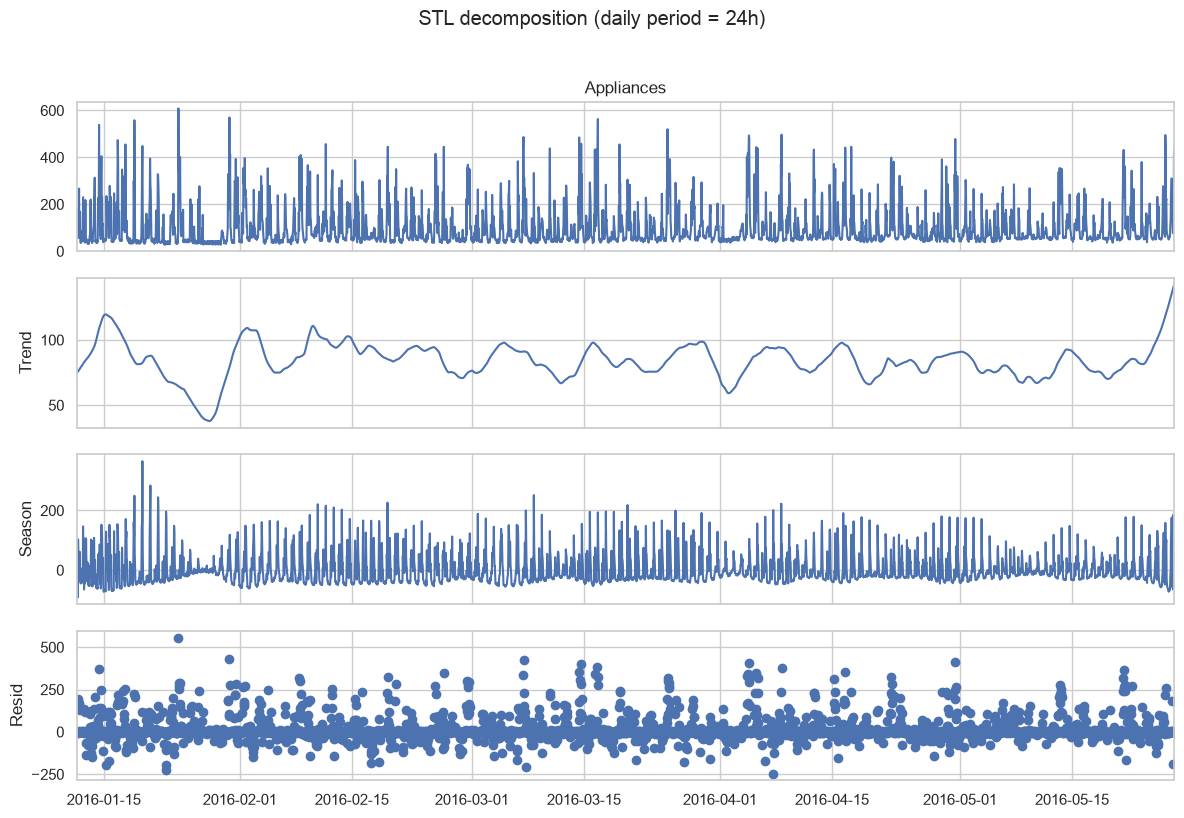

In [6]:
decomposition = D.decompose_series(y, period=config.DAILY_PERIOD, method='stl')
P.plot_decomposition(decomposition, title='STL decomposition (daily period = 24h)')
plt.show()

## ACF / PACF of the raw series

Slow-decaying, oscillating autocorrelation at multiples of 24 lags is the signature of daily seasonality; this motivates a *seasonal* ARIMA (SARIMA) rather than plain ARIMA in Part 4.

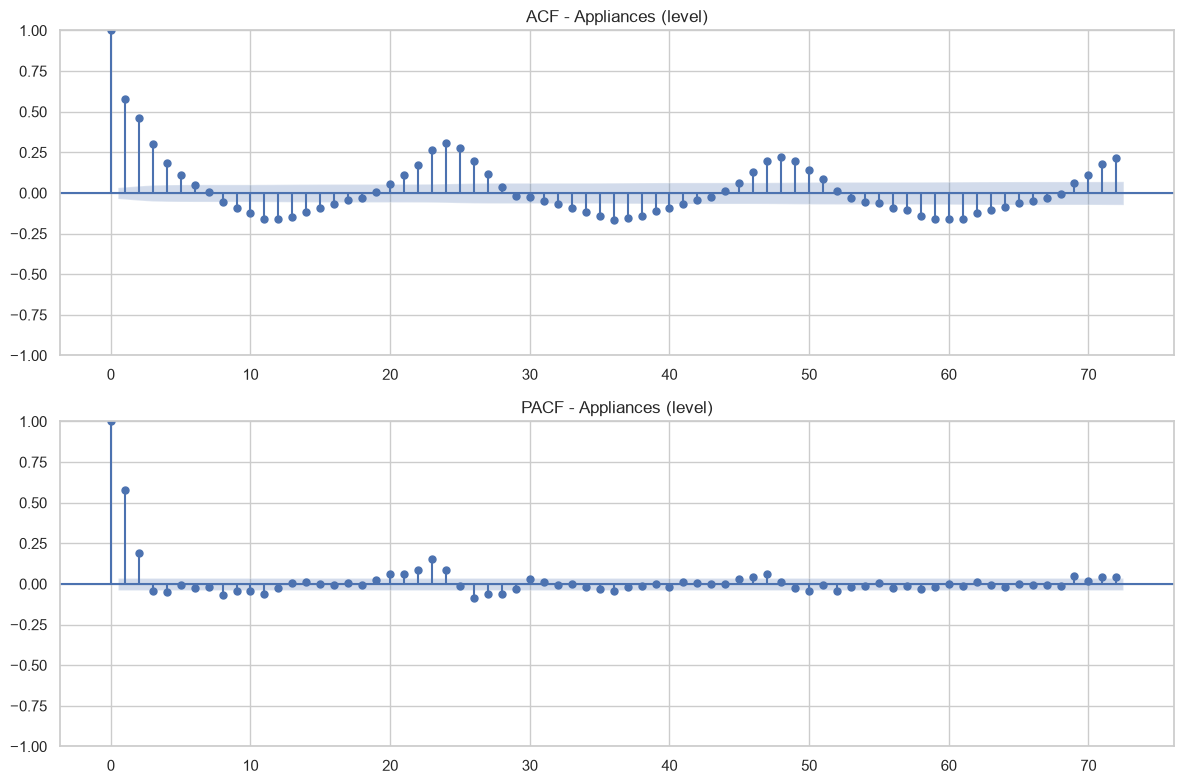

In [7]:
P.plot_acf_pacf(y, lags=72, title_suffix='- Appliances (level)'); plt.show()

## Stationarity tests

We run both the Augmented Dickey-Fuller test (H0: unit root / non-stationary) and the KPSS test (H0: stationary) on the raw level, the first difference, the seasonal (24h) difference, and both differences combined. Using both tests together is more informative than either alone, since they have opposite null hypotheses - agreement between them is much stronger evidence than either test in isolation.

In [8]:
stationarity_table = D.run_stationarity_suite(y, name='Appliances')
stationarity_table[['series', 'test', 'statistic', 'p_value', 'is_stationary_at_5pct']]

/Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/src/appliance_energy/data.py:173: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pvalue, n_lags, crit_values = kpss(series, regression=regression, nlags="auto")
/Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/src/appliance_energy/data.py:173: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pvalue, n_lags, crit_values = kpss(series, regression=regression, nlags="auto")
/Users/moaztahir/Downloads/Herts/Semester C/Data Analysis with AI/Assignment 2/Timeseries-Datascience/src/appliance_energy/data.py:173: InterpolationWarning: The test statistic is outside of the range of p-values avail

,series,test,statistic,p_value,is_stationary_at_5pct
0,Appliances (level),ADF,-8.948888,8.833753e-15,True
1,Appliances (level),KPSS,0.038399,1.000000e-01,True
2,Appliances (first diff),ADF,-16.952574,9.437199e-30,True
3,Appliances (first diff),KPSS,0.078322,1.000000e-01,True
4,"Appliances (seasonal diff, lag=24)",ADF,-13.593417,2.016273e-25,True
5,"Appliances (seasonal diff, lag=24)",KPSS,0.008674,1.000000e-01,True
6,Appliances (first + seasonal diff),ADF,-18.154423,2.470916e-30,True
7,Appliances (first + seasonal diff),KPSS,0.080837,1.000000e-01,True


## ACF / PACF after seasonal differencing

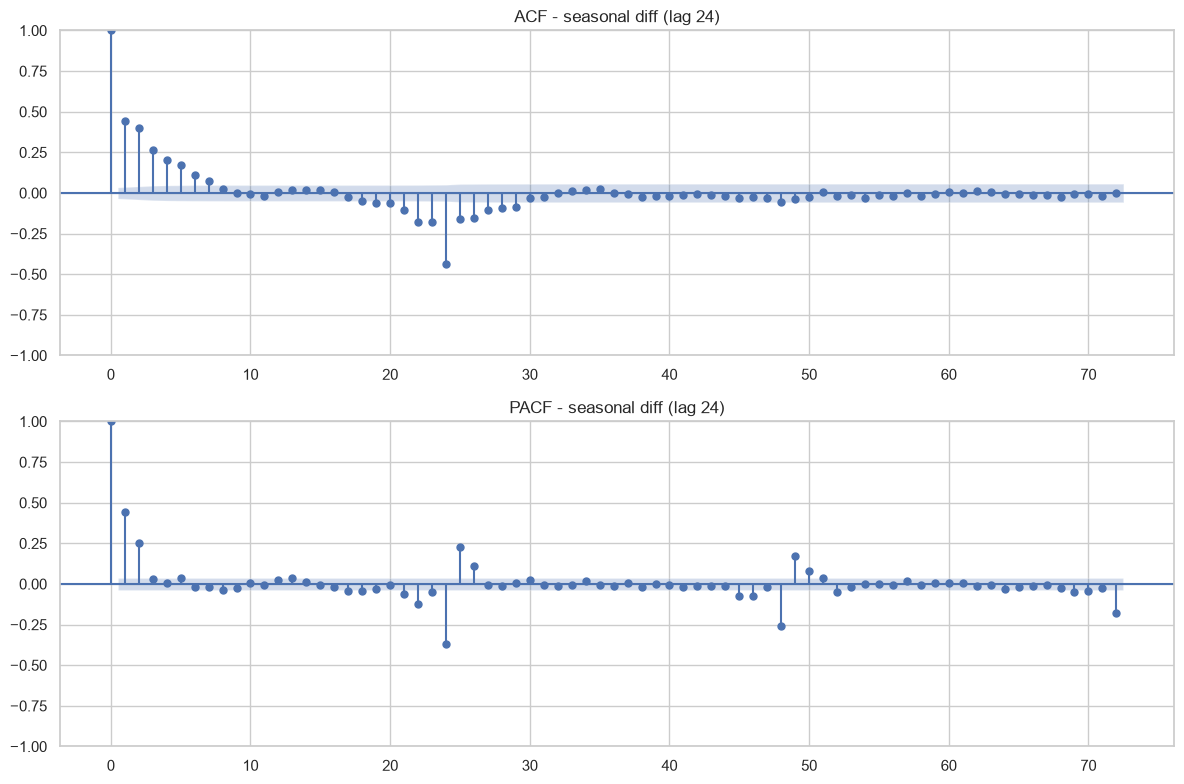

In [9]:
y_seasonal_diff = y.diff(config.DAILY_PERIOD).dropna()
P.plot_acf_pacf(y_seasonal_diff, lags=72, title_suffix='- seasonal diff (lag 24)')
plt.show()

## Correlation with candidate covariates

A quick look at how strongly the target correlates with the outdoor weather variables and a few indoor sensors, to sanity-check the SARIMAX exogenous variable choice in Part 4 and the feature selection in Part 5.

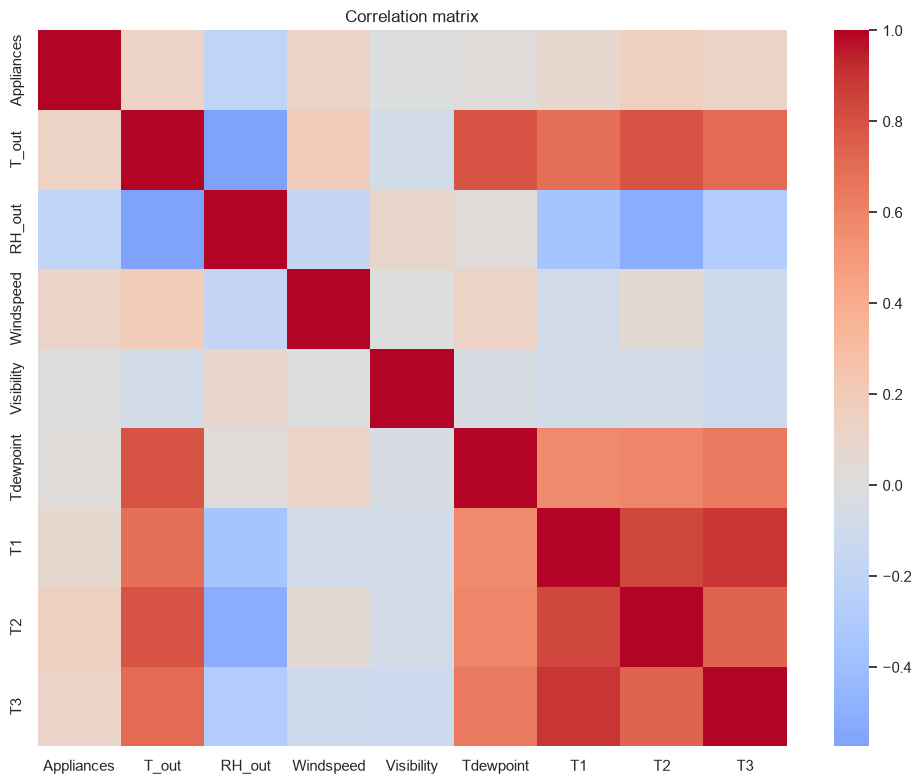

In [10]:
cols = [config.TARGET] + config.SARIMAX_EXOG_COLS + config.INDOOR_TEMP_COLS[:3]
P.plot_correlation_heatmap(hourly, cols)
plt.show()

### Interpretation

- The hourly/weekday boxplots show a clear within-day cycle (low overnight, peaks around breakfast and evening) and a weekday/weekend shift, i.e. both a **daily** and a **weekly** seasonal component are visible directly in the raw data.
- The ADF and KPSS tests on the *level* series often already suggest stationarity in the classical unit-root sense for this dataset - appliance load doesn't drift arbitrarily far the way e.g. a stock price would. That does **not** mean the series has no structure to model: the ACF still shows strong, slowly-decaying autocorrelation at seasonal lags (24, 48, 72, ...), which is exactly the kind of structure a *seasonal* ARIMA term captures even when a unit-root test says the series is "stationary" in the narrow statistical sense.
- This motivates fixing the seasonal order to include `D=1` seasonal differencing at lag 24 for SARIMAX (Part 4), removing the daily cycle before the non-seasonal `(p,d,q)` terms are searched by AIC, rather than jointly grid-searching the seasonal order (computationally unreasonable - see `src/appliance_energy/config.py` for the full reasoning).